# 02613 — How to Solve Every Type of Exam Task
## A Step-by-Step Recipe Book

This notebook gives you a **recipe** for each task type you will encounter.
For each type: read the recipe → apply the steps → get the answer.

---

## Task Types
1. [LSF Job Script — Fix or Write Resources](#task1)
2. [Amdahl's Law — Any Variant](#task2)
3. [Read a Speedup Plot → Find F](#task3)
4. [Threading vs Multiprocessing Decision](#task4)
5. [Static vs Dynamic Scheduling Decision](#task5)
6. [Parallel Reduction — Is it Valid?](#task6)
7. [NumPy Broadcasting — Shape & Indexing](#task7)
8. [Cache Efficiency — Loop Ordering from Strides](#task8)
9. [GPU vs CPU Layout (CUDA)](#task9)
10. [Read cProfile Output — Find Bottleneck](#task10)
11. [Read line_profiler — FLOP/s Calculation](#task11)
12. [Read nsys (GPU Profiler) — Transfer Speed & Total Time](#task12)
13. [CUDA — Number of Thread Blocks](#task13)
14. [CUDA — Memory Transfers (Optimal vs Actual)](#task14)
15. [Pandas — Recode dtypes to Save Memory](#task15)
16. [Chunked Processing — Max Rows per Chunk](#task16)
17. [Zarr — Best Chunk Shape](#task17)
18. [LSF Job Arrays & Dependencies](#task18)
19. [Floating Point Precision](#task19)
20. [time Command — Wall vs CPU Time](#task20)

---

# Task Type 1 — LSF Job Script: Fix or Write Resources

## When you see this task
- "Fix the job script"
- "Write a job script that requests X cores, Y GB, Z minutes"
- "What resources does this job script request?"

---

## Recipe

### Step 1: Identify the 4 key resources
| Resource | Directive | Notes |
|---|---|---|
| Wall time | `#BSUB -W HH:MM` | Max runtime |
| Cores | `#BSUB -n N` | Number of CPU cores |
| Memory | `#BSUB -R "rusage[mem=XGB]"` | **PER CORE**, not total |
| Single node | `#BSUB -R "span[hosts=1]"` | Needed when n > 1 |

### Step 2: Calculate memory per core
$$\text{mem per core} = \frac{\text{total memory}}{\text{number of cores}}$$

### Step 3: GPU? Add queue + gpu directive
```bash
#BSUB -q gpuv100
#BSUB -gpu "num=1:mode=exclusive_process"
```

### Step 4: Watch for typos!
- `#BSUG` instead of `#BSUB` → **that line is ignored**
- Wrong sign: `-–n` vs `-n`

---

## Template Answer
```bash
#!/bin/bash
#BSUB -J jobname
#BSUB -q hpc
#BSUB -W 00:15               ← wall time
#BSUB -n 8                   ← cores
#BSUB -R "span[hosts=1]"     ← required when n > 1
#BSUB -R "rusage[mem=2GB]"   ← memory PER CORE (total=16GB/8=2GB)
#BSUB -o output_%J.out
#BSUB -e errors_%J.err
python script.py
```

---

## Worked Examples

In [1]:
def lsf_memory_per_core(total_gb, n_cores):
    return total_gb / n_cores

def lsf_total_memory(per_core_gb, n_cores):
    return per_core_gb * n_cores

# Example 1: Program needs 16 GB, 8 cores, 15 minutes
print("=== Example 1 ===")
print(f"mem per core = 16 GB / 8 cores = {lsf_memory_per_core(16, 8)} GB")
print("Directives:")
print("  #BSUB -W 00:15")
print("  #BSUB -n 8")
print("  #BSUB -R 'span[hosts=1]'")
print("  #BSUB -R 'rusage[mem=2GB]'")

# Example 2: Script needs 100 GB total, 4 cores
print("\n=== Example 2 ===")
print(f"mem per core = 100 GB / 4 cores = {lsf_memory_per_core(100, 4)} GB")
print("  #BSUB -R 'rusage[mem=25GB]'")

# Example 3: Script requests rusage[mem=4GB] with -n 8. What is total memory?
print("\n=== Example 3: What resources does this request? ===")
print(f"Total memory = 4 GB/core × 8 cores = {lsf_total_memory(4, 8)} GB")
print("Wall time: read from -W directive")
print("Cores: read from -n directive")

=== Example 1 ===
mem per core = 16 GB / 8 cores = 2.0 GB
Directives:
  #BSUB -W 00:15
  #BSUB -n 8
  #BSUB -R 'span[hosts=1]'
  #BSUB -R 'rusage[mem=2GB]'

=== Example 2 ===
mem per core = 100 GB / 4 cores = 25.0 GB
  #BSUB -R 'rusage[mem=25GB]'

=== Example 3: What resources does this request? ===
Total memory = 4 GB/core × 8 cores = 32 GB
Wall time: read from -W directive
Cores: read from -n directive


---
# Task Type 2 — Amdahl's Law: Any Variant

## When you see this task
- "What is the speedup with p cores?"
- "What is the max speedup?"
- "How long does it take on 1 processor?"
- "Should they pursue parallelisation?"
- "Reducing serial time by X — what is the new parallel time?"

---

## Recipe

### The two key formulas
$$S(p) = \frac{1}{(1-F) + F/p} \qquad S_{max} = \frac{1}{1-F}$$

### Step 1: Identify what you know
- Do you have F directly? → use formula
- Do you have S and p? → solve for F
- Do you have serial/parallel times? → calculate F = parallel_time / total_time

### Step 2: Identify what you need to find
- S(p) given F and p → plug into formula
- T_serial from T_parallel: T_serial = T_parallel × S(p)
- New T after reducing serial part: T'_p = T_p − reduction

### Step 3: Compare to a target if asked
- Is S(p) ≥ target? → yes/no
- Use the **best available hardware** (max cores the company has)

---

## All Variants with Code

In [2]:
def amdahl_S(F, p):           return 1 / ((1-F) + F/p)
def amdahl_S_max(F):          return 1 / (1-F)
def amdahl_F_from_S(S, p):   return p*(1 - 1/S) / (p-1)
def amdahl_F_from_times(T_serial, T_parallel): return T_parallel / (T_serial + T_parallel)
def amdahl_T_serial_from_T_parallel(T_p, F, p): return T_p * amdahl_S(F, p)

print("VARIANT A: Calculate S(p) from F and p")
F, p = 0.8, 8
print(f"  F={F}, p={p} → S = {amdahl_S(F, p):.3f}")

print("\nVARIANT B: Calculate max speedup from F")
print(f"  F={F} → S_max = {amdahl_S_max(F):.1f}")

print("\nVARIANT C: Recover serial time from parallel time")
# Program runs in 10 min on 4 cores, F=0.8
T_p, F, p = 10, 0.8, 4
T_1 = amdahl_T_serial_from_T_parallel(T_p, F, p)
print(f"  T({p})={T_p} min, F={F} → S({p})={amdahl_S(F,p):.2f} → T(1) = {T_1:.1f} min")

print("\nVARIANT D: Reduce serial part → new parallel time")
# Original T(4) = 10 min, reduce serial by 3 min
reduction = 3
T_p_new = T_p - reduction
print(f"  T({p}) was {T_p} min. Serial reduced by {reduction} min → T({p}) = {T_p_new} min")
print("  (Only the serial fraction changes — just subtract from total!)") 

print("\nVARIANT E: Should they parallelise? (compare to target)")
F, p_max, target = 0.8, 8, 4
S_best = amdahl_S(F, p_max)
print(f"  F={F}, best machine has {p_max} cores, target={target}x")
print(f"  S({p_max}) = {S_best:.3f} → {'YES ✅' if S_best >= target else 'NO ❌ — cannot reach target'}")

print("\nVARIANT F: Calculate F from serial/parallel times")
T_s, T_p_part = 20, 100
F = amdahl_F_from_times(T_s, T_p_part)
print(f"  T_serial={T_s}s, T_parallel={T_p_part}s → F = {T_p_part}/{T_s+T_p_part} = {F:.4f}")

print("\nVARIANT G: Estimate F from measured speedup")
S_measured, p = 2.5, 3
F_est = amdahl_F_from_S(S_measured, p)
print(f"  S({p})={S_measured} → F = {F_est:.3f}, max speedup = {amdahl_S_max(F_est):.1f}")

VARIANT A: Calculate S(p) from F and p
  F=0.8, p=8 → S = 3.333

VARIANT B: Calculate max speedup from F
  F=0.8 → S_max = 5.0

VARIANT C: Recover serial time from parallel time
  T(4)=10 min, F=0.8 → S(4)=2.50 → T(1) = 25.0 min

VARIANT D: Reduce serial part → new parallel time
  T(4) was 10 min. Serial reduced by 3 min → T(4) = 7 min
  (Only the serial fraction changes — just subtract from total!)

VARIANT E: Should they parallelise? (compare to target)
  F=0.8, best machine has 8 cores, target=4x
  S(8) = 3.333 → NO ❌ — cannot reach target

VARIANT F: Calculate F from serial/parallel times
  T_serial=20s, T_parallel=100s → F = 100/120 = 0.8333

VARIANT G: Estimate F from measured speedup
  S(3)=2.5 → F = 0.900, max speedup = 10.0


---
# Task Type 3 — Read a Speedup Plot → Find F

## When you see this task
- A plot is given where speedup levels off at some value
- "What is the parallel fraction?"

---

## Recipe

### Step 1: Find the plateau
Look at where the speedup curve **stops increasing** and flattens out.
Read off the plateau value (e.g., 5).

### Step 2: Apply the formula
$$F = 1 - \frac{1}{\text{plateau speedup}}$$

### Step 3: Verify by checking other points on the plot
With your estimated F, compute S(p) for a few p values and see if they match the plot.

---

## Example

Plateau = 5 → F = 1 - 1/5 = 0.8

Verification — computed S(p) vs what you'd read off the plot:
  S(1) = 1.00
  S(2) = 1.67
  S(3) = 2.14
  S(4) = 2.50
  S(5) = 2.78


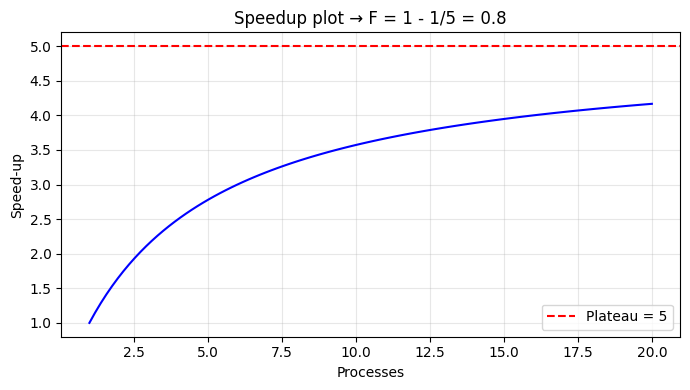

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def amdahl_S(F, p): return 1 / ((1-F) + F/p)

# The plot shows speedup plateauing at ~5
plateau = 5
F = 1 - 1/plateau
print(f"Plateau = {plateau} → F = 1 - 1/{plateau} = {F}")

# Verify against a plot with p = 1,2,3,4,5
ps = [1, 2, 3, 4, 5]
print("\nVerification — computed S(p) vs what you'd read off the plot:")
for p in ps:
    print(f"  S({p}) = {amdahl_S(F, p):.2f}")

# Simulate what the plot looks like
ps_fine = np.linspace(1, 20, 100)
speedups = [amdahl_S(F, p) for p in ps_fine]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ps_fine, speedups, 'b-')
ax.axhline(plateau, color='r', linestyle='--', label=f'Plateau = {plateau}')
ax.set_xlabel('Processes')
ax.set_ylabel('Speed-up')
ax.set_title(f'Speedup plot → F = 1 - 1/{plateau} = {F}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
# Task Type 4 — Threading vs Multiprocessing Decision

## When you see this task
- "What Python parallelisation approach should they use?"
- Options are usually: Multi-threading / Multi-processing / Does not matter

---

## Recipe — 3 Questions to Ask

```
Q1: Is the function pure Python loops?
    YES → GIL blocks threads → MULTIPROCESSING
    NO  → go to Q2

Q2: Does the function use NumPy or has nogil=True (Numba)?
    YES → GIL released → THREADING is fine
    NO  → go to Q3

Q3: Is it I/O-bound (reading files, network)?
    YES → GIL released during I/O → THREADING is fine
    NO  → MULTIPROCESSING
```

---

## Quick Reference Table

| Code type | GIL released? | Use |
|---|---|---|
| `for i in range(n): s += i` | ❌ No | **Multiprocessing** |
| `np.sum(arr)` | ✅ Yes | Threading |
| `@jit(nogil=True)` | ✅ Yes | Threading |
| `@jit` without nogil | ❌ No | Multiprocessing |
| Reading files / network | ✅ Yes | Threading |

---

## Worked Examples

In [4]:
def decide_parallelism(description):
    """
    Simple decision helper.
    In the exam, just read the function and apply the 3 questions.
    """
    pass

examples = [
    {
        'code': 'def process(n):\n    s=0\n    for i in range(n):\n        s+=i\n    return s',
        'answer': 'MULTIPROCESSING',
        'reason': 'Pure Python loop — GIL blocks threading'
    },
    {
        'code': '@jit(nopython=True, nogil=True)\ndef simulate(x0, n):\n    ...',
        'answer': 'THREADING',
        'reason': 'nogil=True → Numba releases GIL → threading works'
    },
    {
        'code': 'def row_sum(row):\n    return row.sum()  # NumPy',
        'answer': 'THREADING',
        'reason': 'NumPy releases GIL during computation'
    },
    {
        'code': 'def simulate_ball(params):\n    while params.height > 0:\n        params = simulate_one_step(params)  # pure Python',
        'answer': 'MULTIPROCESSING',
        'reason': 'simulate_one_step is pure Python → GIL blocks threading'
    },
]

for ex in examples:
    print(f"Code: {ex['code'][:60]}..." if len(ex['code']) > 60 else f"Code:\n{ex['code']}")
    print(f"Answer: {ex['answer']}")
    print(f"Reason: {ex['reason']}")
    print()

Code: def process(n):
    s=0
    for i in range(n):
        s+=i
...
Answer: MULTIPROCESSING
Reason: Pure Python loop — GIL blocks threading

Code:
@jit(nopython=True, nogil=True)
def simulate(x0, n):
    ...
Answer: THREADING
Reason: nogil=True → Numba releases GIL → threading works

Code:
def row_sum(row):
    return row.sum()  # NumPy
Answer: THREADING
Reason: NumPy releases GIL during computation

Code: def simulate_ball(params):
    while params.height > 0:
    ...
Answer: MULTIPROCESSING
Reason: simulate_one_step is pure Python → GIL blocks threading



---
# Task Type 5 — Static vs Dynamic Scheduling

## When you see this task
- "Should they use static or dynamic scheduling?"
- Given a function and input range, or given a StdDev from a profiler

---

## Recipe — 2 Steps

### Step 1: Estimate task time variance
- Does task time **depend on the input**? (e.g., `for i in range(n)` where n varies) → HIGH variance
- Is StdDev large relative to Avg in profiler? → HIGH variance
- Does each task always do the same work? → LOW variance

### Step 2: Decide
| Variance | Schedule | Why |
|---|---|---|
| HIGH | **Dynamic** | Prevents fast workers sitting idle waiting for slow ones |
| LOW | **Static** | Simpler, lower overhead — workers finish at same time |

---

## Key Signals in Exam Questions

In [5]:
examples = [
    {
        'scenario': 'process_number(n) loops n times, n in [1..100_000_000]',
        'variance': 'HIGH — n=1 is instant, n=100M takes a long time',
        'answer': 'DYNAMIC scheduling'
    },
    {
        'scenario': 'Mandelbrot set: points inside set = 100 iters, outside = 1-5 iters',
        'variance': 'HIGH — escape time varies enormously by location',
        'answer': 'DYNAMIC (or small chunks)'
    },
    {
        'scenario': 'Ball simulation: simulate_ball takes minutes to hours depending on design',
        'variance': 'HIGH — explicitly stated',
        'answer': 'DYNAMIC scheduling'
    },
    {
        'scenario': 'Profiler: kernel2 Avg=20ms StdDev=0.05ms',
        'variance': 'LOW — StdDev ≪ Avg',
        'answer': 'STATIC scheduling (overhead of dynamic not worth it)'
    },
    {
        'scenario': 'Profiler: kernel1 Avg=20ms StdDev=40ms',
        'variance': 'HIGH — StdDev > Avg',
        'answer': 'DYNAMIC scheduling'
    },
]

for ex in examples:
    print(f"Scenario: {ex['scenario']}")
    print(f"Variance: {ex['variance']}")
    print(f"Answer:   {ex['answer']}")
    print()

Scenario: process_number(n) loops n times, n in [1..100_000_000]
Variance: HIGH — n=1 is instant, n=100M takes a long time
Answer:   DYNAMIC scheduling

Scenario: Mandelbrot set: points inside set = 100 iters, outside = 1-5 iters
Variance: HIGH — escape time varies enormously by location
Answer:   DYNAMIC (or small chunks)

Scenario: Ball simulation: simulate_ball takes minutes to hours depending on design
Variance: HIGH — explicitly stated
Answer:   DYNAMIC scheduling

Scenario: Profiler: kernel2 Avg=20ms StdDev=0.05ms
Variance: LOW — StdDev ≪ Avg
Answer:   STATIC scheduling (overhead of dynamic not worth it)

Scenario: Profiler: kernel1 Avg=20ms StdDev=40ms
Variance: HIGH — StdDev > Avg
Answer:   DYNAMIC scheduling



---
# Task Type 6 — Parallel Reduction: Is it Valid?

## When you see this task
- "Can this function be used in a parallel reduction?"
- "Why does this function give wrong results in parallel reduction?"

---

## Recipe — 2 Steps

### Step 1: Check associativity
The function `f(a, b)` must satisfy: **`f(f(a,b), c) == f(a, f(b,c))` for ALL inputs**

### Step 2: Find a counter-example (if not associative)
Try `a=1, b=2, c=-3` (mix of positive and negative, works for abs-related functions)

---

## Common Cases

In [6]:
def check_associativity(f, a, b, c, name):
    left  = f(f(a, b), c)
    right = f(a, f(b, c))
    ok = abs(left - right) < 1e-9 if isinstance(left, float) else (left == right)
    print(f"{name}:")
    print(f"  f(f({a},{b}),{c}) = {left}")
    print(f"  f({a},f({b},{c})) = {right}")
    print(f"  Associative? {'✅ YES' if ok else '❌ NO — CANNOT use in parallel reduction'}")
    if not ok:
        print(f"  Fix: compute sum normally, apply |abs| at the end")
    print()

# abs(x+y) — NOT associative (exam 2024 Q6)
check_associativity(lambda x,y: abs(x+y), 1, 2, -3, "abs(x+y)")

# Regular sum — associative
check_associativity(lambda x,y: x+y, 1, 2, -3, "x+y (regular sum)")

# Max — associative
check_associativity(lambda x,y: max(x,y), 1, 5, 3, "max(x,y)")

# Set intersection — associative
def set_intersect(a, b): return a & b
A, B, C = {1,2,3}, {2,3,4}, {3,4,5}
left  = set_intersect(set_intersect(A,B), C)
right = set_intersect(A, set_intersect(B,C))
print(f"Set intersection:")
print(f"  (A∩B)∩C = {left}")
print(f"  A∩(B∩C) = {right}")
print(f"  Associative? {'✅ YES' if left == right else '❌ NO'}")

print()
print("SUMMARY:")
cases = [
    ("x + y (sum)",          "✅ Associative → OK for reduction"),
    ("x * y (product)",      "✅ Associative → OK for reduction"),
    ("max(x,y)",             "✅ Associative → OK for reduction"),
    ("min(x,y)",             "✅ Associative → OK for reduction"),
    ("Set intersection ∩",   "✅ Associative → OK for reduction"),
    ("abs(x+y)",             "❌ NOT associative → CANNOT use in reduction"),
    ("x - y (subtraction)",  "❌ NOT associative → CANNOT use in reduction"),
]
for name, verdict in cases:
    print(f"  {name:<30} {verdict}")

abs(x+y):
  f(f(1,2),-3) = 0
  f(1,f(2,-3)) = 2
  Associative? ❌ NO — CANNOT use in parallel reduction
  Fix: compute sum normally, apply |abs| at the end

x+y (regular sum):
  f(f(1,2),-3) = 0
  f(1,f(2,-3)) = 0
  Associative? ✅ YES

max(x,y):
  f(f(1,5),3) = 5
  f(1,f(5,3)) = 5
  Associative? ✅ YES

Set intersection:
  (A∩B)∩C = {3}
  A∩(B∩C) = {3}
  Associative? ✅ YES

SUMMARY:
  x + y (sum)                    ✅ Associative → OK for reduction
  x * y (product)                ✅ Associative → OK for reduction
  max(x,y)                       ✅ Associative → OK for reduction
  min(x,y)                       ✅ Associative → OK for reduction
  Set intersection ∩             ✅ Associative → OK for reduction
  abs(x+y)                       ❌ NOT associative → CANNOT use in reduction
  x - y (subtraction)            ❌ NOT associative → CANNOT use in reduction


---
# Task Type 7 — NumPy Broadcasting: Shape & Indexing

## When you see this task
- "Which operation achieves this?"
- "What is the shape of c = a + b?"
- "Write code to subtract X from each Y"

---

## Recipe — 4 Steps

### Step 1: Write out both shapes
```
a: (N, H, W, 3)
b: (H, W)
```

### Step 2: Align to the right, left-pad with 1s
```
a: (N, H, W, 3)
b: (1, H, W, 1)  ← padded
```

### Step 3: Check compatibility (each dim: equal or one is 1)
```
N vs 1 → OK    H vs H → OK    W vs W → OK    3 vs 1 → OK
```

### Step 4: Result shape = element-wise max
```
result: (N, H, W, 3)
```

### Adding dimensions with `None` / `np.newaxis`
```python
a[None]        → adds dim at front:     (1, ...)
a[:, None]     → adds dim after axis 0
a[..., None]   → adds dim at end:       (..., 1)
a[:, :, None]  → adds dim after axis 1
```

In [7]:
import numpy as np

def broadcasting_shape(shape_a, shape_b):
    """Step-by-step broadcasting shape calculation."""
    # Pad to same length
    la, lb = len(shape_a), len(shape_b)
    diff = abs(la - lb)
    if la < lb: shape_a = (1,)*diff + tuple(shape_a)
    else:       shape_b = (1,)*diff + tuple(shape_b)
    
    print(f"After padding: a={shape_a}, b={shape_b}")
    result = []
    for i, (da, db) in enumerate(zip(shape_a, shape_b)):
        if da == db:   result.append(da)
        elif da == 1:  result.append(db)
        elif db == 1:  result.append(da)
        else:
            print(f"  Dim {i}: {da} vs {db} — INCOMPATIBLE → Won't broadcast!")
            return None
    print(f"Result shape: {tuple(result)}")
    return tuple(result)

print("=== Re-exam Q10: a=(100,1,6,3), b=(100,1,3) ===")
broadcasting_shape((100,1,6,3), (100,1,3))

print("\n=== Exam Q7: images=(N,H,W,3), mim=(H,W) → subtract mim[:,:,None] ===")
# mim[:,:,None] has shape (H,W,1)
N,H,W = 4,8,8
images = np.zeros((N,H,W,3))
mim = np.zeros((H,W))
result = images - mim[:,:,None]
print(f"mim[:,:,None].shape = {mim[:,:,None].shape}")
print(f"result.shape = {result.shape}")

print("\n=== F25 Q5: images=(N,H,W,3), mean_pixels=(N,3) → subtract per image ===")
mean_pixels = np.zeros((N,3))
result2 = images - mean_pixels[:, None, None, :]
print(f"mean_pixels[:,None,None,:].shape = {mean_pixels[:,None,None,:].shape}")
print(f"result.shape = {result2.shape}")

print("\n=== Outer product: x=(n,), y=(m,) → x[:,None]*y[None,:] ===")
x = np.array([1,2])
y = np.array([3,4,5])
outer = x[:,None] * y[None,:]
print(f"x[:,None].shape={x[:,None].shape}, y[None,:].shape={y[None,:].shape}")
print(f"outer:\n{outer}")

print("\n=== Distance matrix: D[i,j]=|x[i]-y[j]| ===")
x = np.array([1.0, 2.0])
y = np.array([3.0, 0.5, 1.0])
D = np.abs(x[:,None] - y[None,:])
print(f"D =\n{D}")

=== Re-exam Q10: a=(100,1,6,3), b=(100,1,3) ===
After padding: a=(100, 1, 6, 3), b=(1, 100, 1, 3)
Result shape: (100, 100, 6, 3)

=== Exam Q7: images=(N,H,W,3), mim=(H,W) → subtract mim[:,:,None] ===
mim[:,:,None].shape = (8, 8, 1)
result.shape = (4, 8, 8, 3)

=== F25 Q5: images=(N,H,W,3), mean_pixels=(N,3) → subtract per image ===
mean_pixels[:,None,None,:].shape = (4, 1, 1, 3)
result.shape = (4, 8, 8, 3)

=== Outer product: x=(n,), y=(m,) → x[:,None]*y[None,:] ===
x[:,None].shape=(2, 1), y[None,:].shape=(1, 3)
outer:
[[ 3  4  5]
 [ 6  8 10]]

=== Distance matrix: D[i,j]=|x[i]-y[j]| ===
D =
[[2.  0.5 0. ]
 [1.  1.5 1. ]]


---
# Task Type 8 — Cache Efficiency: Loop Ordering from Strides

## When you see this task
- "How would you re-order the loops? Explain."
- "Given strides (a, b, c, d) for axes (i, j, k, l), reorder the loops."

---

## Recipe — 3 Steps

### Step 1: List strides for each axis
Strides = how many bytes to skip per step along that axis.
Smaller stride = elements are closer in memory.

### Step 2: Sort axes by stride
**Innermost loop = smallest stride** (most cache-friendly)
**Outermost loop = largest stride**

### Step 3: Write the new loop order
Sort from largest stride (outer) to smallest stride (inner).

### Key fact for default NumPy arrays (row-major)
**The last axis always has the smallest stride** (= element size in bytes).
So for a standard array, the innermost loop should iterate over the **last axis**.

In [8]:
import numpy as np

def optimal_loop_order(strides_dict):
    """Given {axis_name: stride}, return optimal loop order (outer to inner)."""
    sorted_axes = sorted(strides_dict.items(), key=lambda x: x[1], reverse=True)
    return [axis for axis, stride in sorted_axes]

# Exam 2024 Q8: strides (600, 40, 8, 200) for axes (i, j, k, l)
strides = {'i': 600, 'j': 40, 'k': 8, 'l': 200}
order = optimal_loop_order(strides)
print("=== Exam 2024 Q8 ===")
print(f"Strides: {strides}")
print(f"Optimal loop order (outer → inner): {' → '.join(order)}")
print(f"Innermost (smallest stride): {order[-1]} (stride={strides[order[-1]]})")

print()
print("Rewritten loops:")
print(f"for {order[0]} in range(...):       # stride {strides[order[0]]} — outermost")
print(f"    for {order[1]} in range(...):   # stride {strides[order[1]]}")
print(f"        for {order[2]} in range(...): # stride {strides[order[2]]}")
print(f"            for {order[3]} in range(...): # stride {strides[order[3]]} — innermost")

print()
print("=== How to read strides in Python ===")
arr = np.zeros((5, 10, 3, 25), dtype=np.float32)  # 4 bytes per element
print(f"Shape: {arr.shape}")
print(f"Strides: {arr.strides}")
axes = ['axis0', 'axis1', 'axis2', 'axis3']
for ax, stride in zip(axes, arr.strides):
    print(f"  {ax}: {stride} bytes")

print()
print("Rule: for row-major arrays (default NumPy):")
print("  strides = (shape[-1]*...*itemsize, ..., shape[-1]*itemsize, itemsize)")
print("  → LAST axis ALWAYS has the smallest stride")

=== Exam 2024 Q8 ===
Strides: {'i': 600, 'j': 40, 'k': 8, 'l': 200}
Optimal loop order (outer → inner): i → l → j → k
Innermost (smallest stride): k (stride=8)

Rewritten loops:
for i in range(...):       # stride 600 — outermost
    for l in range(...):   # stride 200
        for j in range(...): # stride 40
            for k in range(...): # stride 8 — innermost

=== How to read strides in Python ===
Shape: (5, 10, 3, 25)
Strides: (3000, 300, 100, 4)
  axis0: 3000 bytes
  axis1: 300 bytes
  axis2: 100 bytes
  axis3: 4 bytes

Rule: for row-major arrays (default NumPy):
  strides = (shape[-1]*...*itemsize, ..., shape[-1]*itemsize, itemsize)
  → LAST axis ALWAYS has the smallest stride


---
# Task Type 9 — GPU vs CPU Array Layout (CUDA)

## When you see this task
- "How should the image array be stored for max cache efficiency?"
- Options are usually channels-first (`C×H×W`) vs channels-last (`H×W×C`)

---

## Recipe — Ask Two Questions

### Question 1: Is this CPU or GPU?

**CPU (parallel for loop over pixels, inner loop over channels):**
- One thread iterates over channels sequentially
- Inner loop = channels → channels must have smallest stride → **last axis**
- ✅ Use `H × W × C` (channels **last**)

**GPU (CUDA, thread block processes pixels simultaneously):**
- All threads in a warp access the **same channel k at the same time**
- For coalesced access: those values must be adjacent in memory
- → Channel values for all `(i,j)` in channel `k` must be contiguous
- ✅ Use `C × H × W` (channels **first**)

### Question 2 (for GPU): Which axis do warp threads vary along?
- In a 2D block `(rows, cols)`: threads vary along **columns (j)** within a warp
- For coalesced access: adjacent j-threads must access adjacent memory
- → The **j-axis** (columns) should have the **smallest stride** → **last dimension**

---

## Summary Table

| Context | Inner loop / warp variation | Best layout |
|---|---|---|
| CPU, inner loop = channels | channels sequential per thread | `H × W × C` |
| GPU, all threads access same channel | channels per warp | `C × H × W` |
| GPU 2D grid, threads vary by j | j-axis should be last | last axis = j-axis |

In [9]:
import numpy as np

print("=== CPU: inner loop over channels → channels LAST ===")
print("""
parallel for i in range(h):
    parallel for j in range(w):
        for k in range(c):          ← inner loop: channels
            o += image[i, j, k] * kernel[k]   ← need image[i,j,k] sequential

For sequential k access: k must be the last axis (smallest stride)
→ Store as H × W × C  (channels last)
""")

print("=== GPU: all threads access same k → channels FIRST ===")
print("""
@cuda.jit
def conv_channels_kernel(image, kernel, out, h, w, c):
    i, j = cuda.grid(2)            ← each thread gets one pixel
    for k in range(c):             ← ALL threads access image[k, i, j] simultaneously
        o += image[k, i, j] * kernel[k]

When all threads read image[k, *, *] at once:
→ channel k values must be contiguous
→ Store as C × H × W  (channels first)
""")

# Demonstrate strides
H, W, C = 8, 8, 3
cpu_layout = np.zeros((H, W, C))  # H×W×C — channels last
gpu_layout = np.zeros((C, H, W))  # C×H×W — channels first
print("CPU layout H×W×C strides:", cpu_layout.strides, "← stride along C (last) =", cpu_layout.strides[-1])
print("GPU layout C×H×W strides:", gpu_layout.strides, "← stride along C (first) =", gpu_layout.strides[0])

=== CPU: inner loop over channels → channels LAST ===

parallel for i in range(h):
    parallel for j in range(w):
        for k in range(c):          ← inner loop: channels
            o += image[i, j, k] * kernel[k]   ← need image[i,j,k] sequential

For sequential k access: k must be the last axis (smallest stride)
→ Store as H × W × C  (channels last)

=== GPU: all threads access same k → channels FIRST ===

@cuda.jit
def conv_channels_kernel(image, kernel, out, h, w, c):
    i, j = cuda.grid(2)            ← each thread gets one pixel
    for k in range(c):             ← ALL threads access image[k, i, j] simultaneously
        o += image[k, i, j] * kernel[k]

When all threads read image[k, *, *] at once:
→ channel k values must be contiguous
→ Store as C × H × W  (channels first)

CPU layout H×W×C strides: (192, 24, 8) ← stride along C (last) = 8
GPU layout C×H×W strides: (512, 64, 8) ← stride along C (first) = 512


---
# Task Type 10 — Read cProfile Output: Find the Bottleneck

## When you see this task
- "How many samples were in the data subset?"
- "Which function should you focus on for the production workload?"

---

## Recipe — 3 Steps

### Step 1: Find sample count from ncalls
Look at the function called once per sample (e.g., `process_sample`).
Its `ncalls` = number of samples in the profiling run.

### Step 2: Estimate production time per function
```
production_time = percall × production_call_count
```
- Called once (load_params, prepare_model): production_time = percall × 1
- Called per sample (process_sample): production_time = percall × n_production

### Step 3: Identify the largest production time
The function with the largest production_time is the bottleneck.

In [10]:
# Exam 2024 profiler output
profile = [
    # (function_name,       ncalls_profiling, percall_s, scales_with_samples)
    ('load_params',         1,     20.009,  False),
    ('prepare_model',       1,     15.013,  False),
    ('process_sample',     10,      0.505,  True),
    ('save',                1,      3.007,  False),
    ('load_data',           1,      1.001,  False),
]

# Step 1: How many samples in profiling?
process_sample = next(r for r in profile if r[0]=='process_sample')
n_profiling = process_sample[1]
print(f"Step 1: process_sample called {n_profiling} times → {n_profiling} samples in profiling")

# Step 2 & 3: Production workload
n_production = 1000
print(f"\nStep 2: Production time estimate ({n_production} samples):")
print(f"{'Function':<20} {'percall':>10} {'prod calls':>12} {'prod time':>12}")
print("-" * 58)
max_time, bottleneck = 0, ''
for name, ncalls, percall, scales in profile:
    prod_calls = n_production if scales else 1
    prod_time  = percall * prod_calls
    flag = " ← BOTTLENECK" if prod_time == max([percall*(n_production if s else 1) for _,_,percall,s in profile]) else ""
    print(f"{name:<20} {percall:>10.3f}s {prod_calls:>12} {prod_time:>11.1f}s{flag}")
    if prod_time > max_time:
        max_time, bottleneck = prod_time, name

print(f"\nStep 3: Focus on '{bottleneck}' ({max_time:.0f}s in production — dominates!)")

Step 1: process_sample called 10 times → 10 samples in profiling

Step 2: Production time estimate (1000 samples):
Function                percall   prod calls    prod time
----------------------------------------------------------
load_params              20.009s            1        20.0s
prepare_model            15.013s            1        15.0s
process_sample            0.505s         1000       505.0s ← BOTTLENECK
save                      3.007s            1         3.0s
load_data                 1.001s            1         1.0s

Step 3: Focus on 'process_sample' (505s in production — dominates!)


---
# Task Type 11 — line_profiler: FLOP/s Calculation

## When you see this task
- "How many FLOP/s does the function achieve?"
- "How many steps did the simulation run for?"

---

## Recipe — 4 Steps

### Step 1: Find n_steps from Hits
The loop body lines have `Hits = n_steps`.
The `for` line itself has `Hits = n_steps + 1` (one extra to detect end).

### Step 2: Count FLOPs per iteration
```
+, -, *, /  = 1 FLOP each
sqrt, sin, cos, arctan, arcsin = 1 FLOP each
x[i]*x[i]+4 = 2 FLOPs (1 multiply + 1 add)
y/x         = 1 FLOP
z + a/b     = 2 FLOPs (1 divide + 1 add)
```

### Step 3: Sum total time from all lines (in the given unit)
Sum the `Time` column for ALL lines in the function (usually in µs).
Convert to seconds: divide by 1,000,000.

### Step 4: FLOP/s = total_FLOPs / total_time_seconds

In [11]:
def calculate_flops(lines, time_unit_seconds=1e-6):
    """
    lines: list of (hits, time_in_units, flops_per_hit, description)
    time_unit_seconds: 1e-6 for microseconds (default in line_profiler)
    """
    total_flops = sum(hits * flops for hits, _, flops, _ in lines)
    total_time_s = sum(time for _, time, _, _ in lines) * time_unit_seconds
    
    print(f"{'Hits':>8} {'Time(µs)':>10} {'FLOPs/iter':>12} {'Total FLOPs':>13}  Line")
    print("-" * 70)
    for hits, time, flops, desc in lines:
        print(f"{hits:>8} {time:>10.1f} {flops:>12} {hits*flops:>13}  {desc}")
    print("-" * 70)
    print(f"Total FLOPs: {total_flops:,}")
    print(f"Total time:  {total_time_s*1000:.3f} ms = {total_time_s:.6f} s")
    print(f"FLOP/s:      {total_flops/total_time_s:.3e}")
    return total_flops / total_time_s

# Re-exam 2024 Q8:
# Line 7: for i in range(n_steps)  — 10001 hits, 2000 µs, 0 FLOPs
# Line 8: a = x[i]*x[i]+4         — 10000 hits, 5000 µs, 2 FLOPs (mul + add)
# Line 9: b = y[n-i-1]/x[i]       — 10000 hits, 5000 µs, 1 FLOP (div)
# Line 10: z = z + a/b            — 10000 hits, 3000 µs, 2 FLOPs (div + add)
print("=== Re-exam 2024 Q8 ===")
lines = [
    (10001, 2000.0, 0, 'for i in range(n_steps)'),
    (10000, 5000.0, 2, 'a = x[i]*x[i] + 4'),
    (10000, 5000.0, 1, 'b = y[n-i-1] / x[i]'),
    (10000, 3000.0, 2, 'z = z + a / b'),
]
flops_per_s = calculate_flops(lines)
print(f"\nAnswer: ~{flops_per_s:.2e} FLOP/s ≈ 3.33×10⁶ FLOP/s")

print()
print("=== How to count FLOPs for common expressions ===")
expressions = [
    ('x[i] * x[i] + 4',        2, '1 multiply + 1 add'),
    ('y[n-i-1] / x[i]',        1, '1 divide'),
    ('z + a / b',               2, '1 divide + 1 add'),
    ('np.sqrt(a)',              1, '1 sqrt'),
    ('np.arctan2(sq_a, sq_b)',  1, '1 arctan'),
    ('np.arcsin(sq_a)',         1, '1 arcsin (faster: 1 sqrt saved!)'),
    ('x * x + 4 * y',          3, '1 mul + 1 mul + 1 add'),
]
print(f"{'Expression':<35} {'FLOPs':>6}  Breakdown")
print("-" * 70)
for expr, flops, breakdown in expressions:
    print(f"{expr:<35} {flops:>6}  {breakdown}")

=== Re-exam 2024 Q8 ===
    Hits   Time(µs)   FLOPs/iter   Total FLOPs  Line
----------------------------------------------------------------------
   10001     2000.0            0             0  for i in range(n_steps)
   10000     5000.0            2         20000  a = x[i]*x[i] + 4
   10000     5000.0            1         10000  b = y[n-i-1] / x[i]
   10000     3000.0            2         20000  z = z + a / b
----------------------------------------------------------------------
Total FLOPs: 50,000
Total time:  15.000 ms = 0.015000 s
FLOP/s:      3.333e+06

Answer: ~3.33e+06 FLOP/s ≈ 3.33×10⁶ FLOP/s

=== How to count FLOPs for common expressions ===
Expression                           FLOPs  Breakdown
----------------------------------------------------------------------
x[i] * x[i] + 4                          2  1 multiply + 1 add
y[n-i-1] / x[i]                          1  1 divide
z + a / b                                2  1 divide + 1 add
np.sqrt(a)                           

---
# Task Type 12 — nsys (GPU Profiler): Transfer Speed & Total Time

## When you see this task
- "What is the transfer speed from CPU to GPU?"
- "How much faster is the GPU version?"

---

## Recipe

### Transfer speed
$$\text{speed (GB/s)} = \frac{\text{Total Size (MB)}}{\text{Total Time (s)} \times 1000}$$

### Watch for the zero-size transfer trap!
When Count=2 but one transfer has size ~0 MB:
- Real data transferred ≈ Max MB (the non-zero transfer)
- Real transfer time ≈ Total Time (most time is for the real transfer)

### Total GPU pipeline time
$$T_{GPU} = T_{kernel} + T_{HtoD} + T_{DtoH}$$

### Speedup vs CPU
$$\text{speedup} = \frac{T_{CPU}}{T_{GPU}}$$

In [12]:
def nsys_analysis(kernel_s, htod_s, dtoh_s, htod_mb, dtoh_mb, cpu_s=None):
    T_gpu = kernel_s + htod_s + dtoh_s
    
    print(f"Kernel time:  {kernel_s:.3f} s")
    print(f"HtoD time:    {htod_s:.3f} s   ({htod_mb:.0f} MB)")
    print(f"DtoH time:    {dtoh_s:.3f} s   ({dtoh_mb:.0f} MB)")
    print(f"Total GPU:    {T_gpu:.3f} s")
    
    # Transfer speeds
    htod_speed = htod_mb / htod_s / 1000  # GB/s
    dtoh_speed = dtoh_mb / dtoh_s / 1000  # GB/s
    print(f"\nHtoD speed:   {htod_mb:.0f} MB / {htod_s:.3f} s = {htod_speed:.1f} GB/s")
    print(f"DtoH speed:   {dtoh_mb:.0f} MB / {dtoh_s:.3f} s = {dtoh_speed:.1f} GB/s")
    
    if cpu_s:
        speedup = cpu_s / T_gpu
        print(f"\nCPU time:     {cpu_s:.1f} s")
        print(f"Speedup:      {cpu_s:.1f} / {T_gpu:.1f} = {speedup:.1f}x")
    
    # What takes most time?
    times = {'kernel': kernel_s, 'HtoD': htod_s, 'DtoH': dtoh_s}
    slowest = max(times, key=times.get)
    print(f"\nBottleneck: {slowest} ({times[slowest]:.3f} s is largest)")

print("=== Exam 2024 Q13/Q14 ===")
# HtoD: 2.5s, 25000 MB total but count=2, med=12500, min=0
# → one transfer is ~0 MB, real data ≈ 25000 MB in 2.5s
nsys_analysis(
    kernel_s=0.5,
    htod_s=2.5, htod_mb=25000,
    dtoh_s=0.5, dtoh_mb=1000,
    cpu_s=7.0
)

print()
print("=== F25 Q14 ===")
nsys_analysis(
    kernel_s=13.8/1000,   # ms → s
    htod_s=26.8/1000, htod_mb=125,
    dtoh_s=0.16/1000, dtoh_mb=2,
)

=== Exam 2024 Q13/Q14 ===
Kernel time:  0.500 s
HtoD time:    2.500 s   (25000 MB)
DtoH time:    0.500 s   (1000 MB)
Total GPU:    3.500 s

HtoD speed:   25000 MB / 2.500 s = 10.0 GB/s
DtoH speed:   1000 MB / 0.500 s = 2.0 GB/s

CPU time:     7.0 s
Speedup:      7.0 / 3.5 = 2.0x

Bottleneck: HtoD (2.500 s is largest)

=== F25 Q14 ===
Kernel time:  0.014 s
HtoD time:    0.027 s   (125 MB)
DtoH time:    0.000 s   (2 MB)
Total GPU:    0.041 s

HtoD speed:   125 MB / 0.027 s = 4.7 GB/s
DtoH speed:   2 MB / 0.000 s = 12.5 GB/s

Bottleneck: HtoD (0.027 s is largest)


---
# Task Type 13 — CUDA: Number of Thread Blocks

## When you see this task
- "How many thread blocks are needed for a 200×200 output with 16×16 blocks?"

---

## Recipe — 1 Formula

$$\text{blocks per dim} = \left\lceil \frac{\text{output size along that dim}}{\text{threads per block along that dim}} \right\rceil$$

Apply **independently** for each dimension.

In [13]:
import math

def thread_blocks_needed(output_shape, threads_per_block):
    """
    output_shape: tuple of output dimensions (H, W) or (H, W, D)
    threads_per_block: tuple matching output_shape dimensions
    """
    blocks = tuple(math.ceil(o/t) for o, t in zip(output_shape, threads_per_block))
    total  = math.prod(blocks)
    print(f"Output:  {output_shape}")
    print(f"TPB:     {threads_per_block}")
    print(f"Blocks:  {' × '.join(f'⌈{o}/{t}⌉={b}' for o,t,b in zip(output_shape, threads_per_block, blocks))}")
    print(f"Result:  {blocks} = {total} total blocks")
    return blocks

print("=== F25 Q13: 200×200 output, 16×16 blocks ===")
thread_blocks_needed((200, 200), (16, 16))

print()
print("=== General: 500×500 output, 32×32 blocks ===")
thread_blocks_needed((500, 500), (32, 32))

print()
print("Rule: always use ceil — even if output isn't divisible by block size")
print("The extra threads are handled by: if i < output_h and j < output_w:")

=== F25 Q13: 200×200 output, 16×16 blocks ===
Output:  (200, 200)
TPB:     (16, 16)
Blocks:  ⌈200/16⌉=13 × ⌈200/16⌉=13
Result:  (13, 13) = 169 total blocks

=== General: 500×500 output, 32×32 blocks ===
Output:  (500, 500)
TPB:     (32, 32)
Blocks:  ⌈500/32⌉=16 × ⌈500/32⌉=16
Result:  (16, 16) = 256 total blocks

Rule: always use ceil — even if output isn't divisible by block size
The extra threads are handled by: if i < output_h and j < output_w:


---
# Task Type 14 — CUDA: Memory Transfers (Actual vs Optimal)

## When you see this task
- "How many HtoD and DtoH transfers will this code perform?"
- "How many are needed in an optimal implementation?"

---

## Recipe

### Rule: NumPy array passed to CUDA kernel → auto-transferred both ways
Each NumPy array in a kernel call:
- 1 HtoD (copy to GPU before kernel)
- 1 DtoH (copy back after kernel)

### Optimal: only transfer what's needed
- **Input-only** arrays: only need 1 HtoD (no DtoH)
- **Output-only** arrays: allocate on GPU with `cuda.device_array()` → only 1 DtoH at the end
- **In-loop arrays**: transfer input once per loop, keep output on GPU, DtoH once at end

In [14]:
# Re-exam 2024 Q13/Q14
print("=== CURRENT CODE ===")
print("""
def sumavg(x_all, ...):
    y = np.zeros(...)          # NumPy array on HOST
    for x in x_all:            # 100 images
        kernel[...](x, y, ...) # BOTH x and y are NumPy → auto-transfer!
    return y

Per iteration: x → HtoD, y → HtoD, kernel runs, x ← DtoH, y ← DtoH
= 2 HtoD + 2 DtoH per iteration × 100 iterations = 200 HtoD + 200 DtoH
""")

print("=== OPTIMAL CODE ===")
print("""
from numba import cuda
def sumavg_optimal(x_all, ...):
    y_gpu = cuda.device_array(x_all.shape[1:])  # allocate DIRECTLY on GPU
    for x in x_all:
        x_gpu = cuda.to_device(x)               # 1 HtoD per image
        kernel[...](x_gpu, y_gpu, ...)           # no auto-transfer (both on GPU)
    return y_gpu.copy_to_host()                  # 1 DtoH at the end

= 100 HtoD (one per image) + 1 DtoH (final result) = 101 transfers total
""")

# F25 Q15: square kernel
print("=== F25 Q15: square[1024*1024, 1024](y, x) with NumPy arrays ===")
print("""
Both x and y are NumPy:
  x: input  → HtoD (needed for GPU) + DtoH (auto-returned)
  y: output → HtoD (Numba copies it) + DtoH (auto-returned)
  = 2 HtoD + 2 DtoH

Optimal:
  x: input only  → 1 HtoD, no DtoH needed
  y: output only → allocate on GPU, 1 DtoH at end
  = 1 HtoD + 1 DtoH
""")

=== CURRENT CODE ===

def sumavg(x_all, ...):
    y = np.zeros(...)          # NumPy array on HOST
    for x in x_all:            # 100 images
        kernel[...](x, y, ...) # BOTH x and y are NumPy → auto-transfer!
    return y

Per iteration: x → HtoD, y → HtoD, kernel runs, x ← DtoH, y ← DtoH
= 2 HtoD + 2 DtoH per iteration × 100 iterations = 200 HtoD + 200 DtoH

=== OPTIMAL CODE ===

from numba import cuda
def sumavg_optimal(x_all, ...):
    y_gpu = cuda.device_array(x_all.shape[1:])  # allocate DIRECTLY on GPU
    for x in x_all:
        x_gpu = cuda.to_device(x)               # 1 HtoD per image
        kernel[...](x_gpu, y_gpu, ...)           # no auto-transfer (both on GPU)
    return y_gpu.copy_to_host()                  # 1 DtoH at the end

= 100 HtoD (one per image) + 1 DtoH (final result) = 101 transfers total

=== F25 Q15: square[1024*1024, 1024](y, x) with NumPy arrays ===

Both x and y are NumPy:
  x: input  → HtoD (needed for GPU) + DtoH (auto-returned)
  y: output → Hto

---
# Task Type 15 — Pandas: Recode dtypes to Save Memory

## When you see this task
- "How would you recode each column to reduce memory?"

---

## Recipe — For Each Column, Ask 3 Questions

### Q1: Is it stored as `object` (string)?
- Looks like dates → convert to `datetime64`
- Few unique values (≤ ~255) → convert to `category` or `uint8`

### Q2: Is it an integer?
- Find [min, max] range
- Find the smallest int type that fits

### Q3: Is it a float?
- If precision allows → `float32` instead of `float64`

In [15]:
import numpy as np

# Integer type ranges — memorize or compute
print("=== INTEGER TYPE RANGES ===")
for dt in [np.int8, np.uint8, np.int16, np.uint16, np.int32, np.uint32, np.int64, np.uint64]:
    info = np.iinfo(dt)
    print(f"  {dt.__name__:<8}: [{info.min:>20,}  ..  {info.max:>20,}]  ({np.dtype(dt).itemsize} bytes)")

def smallest_int_dtype(val_min, val_max):
    """Find the smallest NumPy integer dtype that fits [val_min, val_max]."""
    for dt in [np.int8, np.uint8, np.int16, np.uint16, np.int32, np.uint32, np.int64]:
        info = np.iinfo(dt)
        if info.min <= val_min and val_max <= info.max:
            return dt.__name__, np.dtype(dt).itemsize
    return 'int64', 8

print()
print("=== EXAM 2024 Q15 ===")
columns = [
    ('date',     'object', 70079,  None,         None,      'string dates → datetime64'),
    ('location', 'object', 8,      None,         None,      '8 unique → category (uint8 index)'),
    ('mach_id',  'int64',  5731,   -1,           5730,      None),
    ('units',    'int64',  43923,  932,          68837,      None),
]
print(f"{'Column':<12} {'#unique':>8} {'min':>8} {'max':>8}  {'Recode to':<20} Reason")
print("-"*85)
for name, dtype, nunique, vmin, vmax, override in columns:
    if override:
        recode, reason = override.split(' → ') if ' → ' in override else (override, '')
    else:
        recode, nbytes = smallest_int_dtype(vmin, vmax)
        reason = f"range [{vmin},{vmax}] fits in {recode}"
    min_str = str(vmin) if vmin is not None else 'N/A'
    max_str = str(vmax) if vmax is not None else 'N/A'
    print(f"{name:<12} {nunique:>8} {min_str:>8} {max_str:>8}  {recode:<20} {reason}")

=== INTEGER TYPE RANGES ===
  int8    : [                -128  ..                   127]  (1 bytes)
  uint8   : [                   0  ..                   255]  (1 bytes)
  int16   : [             -32,768  ..                32,767]  (2 bytes)
  uint16  : [                   0  ..                65,535]  (2 bytes)
  int32   : [      -2,147,483,648  ..         2,147,483,647]  (4 bytes)
  uint32  : [                   0  ..         4,294,967,295]  (4 bytes)
  int64   : [-9,223,372,036,854,775,808  ..  9,223,372,036,854,775,807]  (8 bytes)
  uint64  : [                   0  ..  18,446,744,073,709,551,615]  (8 bytes)

=== EXAM 2024 Q15 ===
Column        #unique      min      max  Recode to            Reason
-------------------------------------------------------------------------------------
date            70079      N/A      N/A  string dates         datetime64
location            8      N/A      N/A  8 unique             category (uint8 index)
mach_id          5731       -1     5730  in

---
# Task Type 16 — Chunked Processing: Max Rows per Chunk

## When you see this task
- "What is the maximum number of rows that can fit in each chunk?"
- Given: column dtypes and memory budget

---

## Recipe — 3 Steps

### Step 1: bytes per row = sum of dtype sizes
### Step 2: budget in bytes = budget_MB × 1,000,000
### Step 3: max rows = budget_bytes // bytes_per_row

In [16]:
import numpy as np

def max_chunk_rows(dtypes, budget_mb):
    bytes_per_row = sum(np.dtype(dt).itemsize for dt in dtypes)
    budget_bytes  = budget_mb * 1_000_000
    max_rows      = budget_bytes // bytes_per_row
    print(f"Columns: {[np.dtype(dt).name for dt in dtypes]}")
    print(f"Bytes per column: {[np.dtype(dt).itemsize for dt in dtypes]}")
    print(f"Bytes per row: {bytes_per_row}")
    print(f"Budget: {budget_mb} MB = {budget_bytes:,} bytes")
    print(f"Max rows: {budget_bytes:,} / {bytes_per_row} = {max_rows:,}")
    return max_rows

print("=== Exam 2024 Q17 ===")
max_chunk_rows([np.uint32, np.uint64, np.float64], budget_mb=200)

print()
print("=== F25 Q18: 3 × int64 columns, 24 MB ===")
max_chunk_rows([np.int64, np.int64, np.int64], budget_mb=24)

=== Exam 2024 Q17 ===
Columns: ['uint32', 'uint64', 'float64']
Bytes per column: [4, 8, 8]
Bytes per row: 20
Budget: 200 MB = 200,000,000 bytes
Max rows: 200,000,000 / 20 = 10,000,000

=== F25 Q18: 3 × int64 columns, 24 MB ===
Columns: ['int64', 'int64', 'int64']
Bytes per column: [8, 8, 8]
Bytes per row: 24
Budget: 24 MB = 24,000,000 bytes
Max rows: 24,000,000 / 24 = 1,000,000


1000000

---
# Task Type 17 — Zarr: Best Chunk Shape

## When you see this task
- "Which block shape gives best performance for this access pattern?"

---

## Recipe — 2 Steps

### Step 1: Identify the access pattern
- `x[i, :]` → reads a full **row** each time
- `x[:, j]` → reads a full **column** each time
- `x[i, j, k]` → single element (random access)

### Step 2: Choose chunk shape to minimize disk reads per access
- Full rows → chunk must span full row width: `(1, ncols)` or `(small, ncols)`
- Full cols → chunk must span full col height: `(nrows, 1)` or `(nrows, small)`
- Minimize: **# chunks needed to satisfy one access**

In [17]:
import math

def zarr_chunks_needed(array_shape, chunk_shape, access_shape):
    """
    array_shape:  shape of the full array
    chunk_shape:  shape of one chunk
    access_shape: shape of one access (e.g., (1, ncols) for a full row)
    """
    chunks = tuple(math.ceil(a/c) for a, c in zip(access_shape, chunk_shape))
    total  = math.prod(chunks)
    return total

# Re-exam Q5: 1000×100000 matrix, read full columns x[:,j]
print("=== Re-exam Q5: 1000×100000 array, reading full columns ===")
print("Access pattern: x[:, j] = shape (1000, 1) per column")
print()

array_shape  = (1000, 100000)
access_shape = (1000, 1)  # full column

options = [
    (10,   10000, 'a'),
    (100,  1000,  'b'),
    (1000, 100,   'c'),
]
print(f"{'Option':<10} {'Chunk':>15} {'Reads per column':>20}  Verdict")
print("-" * 65)
for rows, cols, label in options:
    n_reads = zarr_chunks_needed(array_shape, (rows, cols), access_shape)
    verdict = "✅ BEST" if n_reads == 1 else "❌"
    print(f"({label}) {label:<7} ({rows:4d}, {cols:5d}) {n_reads:>20}  {verdict}")

print()
print("=== F25 Q20: 1024×1024 array, reading full rows ===")
print("Access pattern: a[i] = shape (1, 1024) per iteration")
access_row = (1, 1024)
options_row = [
    ((1, 1024), 'A'),
    ((1024, 1), 'B'),
    ((32, 32),  'C'),
]
print(f"{'Option':<10} {'Chunk':>15} {'Reads per row':>15}  Verdict")
print("-" * 55)
for chunk, label in options_row:
    n_reads = zarr_chunks_needed((1024, 1024), chunk, access_row)
    verdict = "✅ BEST" if n_reads == 1 else "❌"
    print(f"({label}) {label:<7} {str(chunk):>15} {n_reads:>15}  {verdict}")

=== Re-exam Q5: 1000×100000 array, reading full columns ===
Access pattern: x[:, j] = shape (1000, 1) per column

Option               Chunk     Reads per column  Verdict
-----------------------------------------------------------------
(a) a       (  10, 10000)                  100  ❌
(b) b       ( 100,  1000)                   10  ❌
(c) c       (1000,   100)                    1  ✅ BEST

=== F25 Q20: 1024×1024 array, reading full rows ===
Access pattern: a[i] = shape (1, 1024) per iteration
Option               Chunk   Reads per row  Verdict
-------------------------------------------------------
(A) A             (1, 1024)               1  ✅ BEST
(B) B             (1024, 1)            1024  ❌
(C) C              (32, 32)              32  ❌


---
# Task Type 18 — LSF Job Arrays & Dependencies

## When you see this task
- "When will the dependent job start?"
- "What must be added to make a job run after the array finishes?"

---

## Recipe

### Adding a dependency
```bash
#BSUB -w done(jobname)    # ALL jobs must finish SUCCESSFULLY (DONE state)
#BSUB -w ended(jobname)   # ALL jobs must finish (DONE or EXIT state)
```

### Reading bjobs -A output
```
NJOBS  PEND  DONE  RUN  EXIT
10     0     4     5    1      ← 1 in EXIT!
```

### Decision table
| Dependency | EXIT jobs? | Will it start? |
|---|---|---|
| `done(name)` | 0 | ✅ Yes (once all RUN finish to DONE) |
| `done(name)` | ≥ 1 | ❌ **Never** — EXIT breaks `done()` |
| `ended(name)` | any | ✅ Yes (once all have ended, DONE or EXIT) |

### Exam pattern: the question says "it does not matter if some fail"
→ use `ended()` not `done()`

In [18]:
def will_job_start(dependency_type, n_exit):
    if dependency_type == 'done':
        if n_exit == 0:
            return True, "All jobs can finish DONE → condition satisfied"
        else:
            return False, f"{n_exit} job(s) already in EXIT → done() NEVER satisfied"
    elif dependency_type == 'ended':
        return True, "ended() accepts DONE or EXIT → condition will be satisfied"

# Re-exam Q15 & Exam Q18
print("=== Re-exam Q15: done(prepare), 1 EXIT job ===")
starts, reason = will_job_start('done', n_exit=1)
print(f"Will it start? {'YES ✅' if starts else 'NO ❌ — NEVER'}")
print(f"Reason: {reason}")

print()
print("=== Exam 2024 Q18: 'does not matter if some fail' → use ended() ===")
print("Add to the dependent job script:")
print("  #BSUB -w ended(power)")
print()
starts, reason = will_job_start('ended', n_exit=3)
print(f"With ended(): will start? {'YES ✅' if starts else 'NO ❌'}")
print(f"Reason: {reason}")

=== Re-exam Q15: done(prepare), 1 EXIT job ===
Will it start? NO ❌ — NEVER
Reason: 1 job(s) already in EXIT → done() NEVER satisfied

=== Exam 2024 Q18: 'does not matter if some fail' → use ended() ===
Add to the dependent job script:
  #BSUB -w ended(power)

With ended(): will start? YES ✅
Reason: ended() accepts DONE or EXIT → condition will be satisfied


---
# Task Type 19 — Floating Point Precision

## When you see this task
- "What does `np.array(10000, dtype='float16') + 1` print?"

---

## Recipe — 2 Steps

### Step 1: Find absolute precision at the given value
$$\text{absolute precision} = \text{value} \times \text{resolution}$$
- float16 resolution ≈ 0.001 (3 significant digits)
- float32 resolution ≈ 1e-7
- float64 resolution ≈ 1e-15

### Step 2: Can the increment be represented?
If `increment < absolute_precision` → rounds to original value
If `increment ≥ absolute_precision` → result is representable

In [19]:
import numpy as np

def float_precision_check(value, increment, dtype):
    resolution = np.finfo(dtype).resolution
    abs_precision = abs(value) * resolution
    
    print(f"dtype={dtype.__name__}, resolution={resolution}")
    print(f"value={value}, increment={increment}")
    print(f"Absolute precision at {value}: {value} × {resolution} = {abs_precision}")
    
    if increment < abs_precision:
        print(f"increment ({increment}) < abs_precision ({abs_precision:.2f}) → rounds to {value}")
    else:
        print(f"increment ({increment}) ≥ abs_precision → representable")
    
    # Actual NumPy result
    a = np.array(value, dtype=dtype)
    b = np.array(increment, dtype=dtype)
    print(f"NumPy result: {a} + {b} = {a + b}")
    print()

# F25 Q2
print("=== F25 Q2: 10000 + 1 in float16 ===")
float_precision_check(10000, 1, np.float16)

print("=== Same in float32 ===")
float_precision_check(10000, 1, np.float32)

print("=== What about 10000 + 10 in float16? ===")
float_precision_check(10000, 10, np.float16)

=== F25 Q2: 10000 + 1 in float16 ===
dtype=float16, resolution=0.0010004043579101562
value=10000, increment=1
Absolute precision at 10000: 10000 × 0.0010004043579101562 = 10.0078125
increment (1) < abs_precision (10.01) → rounds to 10000
NumPy result: 10000.0 + 1.0 = 10000.0

=== Same in float32 ===
dtype=float32, resolution=9.999999974752427e-07
value=10000, increment=1
Absolute precision at 10000: 10000 × 9.999999974752427e-07 = 0.009999999776482582
increment (1) ≥ abs_precision → representable
NumPy result: 10000.0 + 1.0 = 10001.0

=== What about 10000 + 10 in float16? ===
dtype=float16, resolution=0.0010004043579101562
value=10000, increment=10
Absolute precision at 10000: 10000 × 0.0010004043579101562 = 10.0078125
increment (10) < abs_precision (10.01) → rounds to 10000
NumPy result: 10000.0 + 10.0 = 10008.0



---
# Task Type 20 — `time` Command: Wall vs CPU Time

## When you see this task
- "After parallelising on 2 cores, what is the expected `time` output?"

---

## Recipe

### The three `time` output lines
| Line | Measures | With parallelism |
|---|---|---|
| `real` | Wall-clock time (what you wait) | **Divided by cores** |
| `user` | CPU time in user mode (summed across cores) | **Stays the same** |
| `sys` | CPU time in kernel mode | Approximately same |

### Key formula
- Single core: real ≈ user ≈ total CPU work
- With p cores (perfect parallel): real ≈ user/p, user stays same

### Example (F25 Q9)
```
Single core:     real=12s  user=12s
2 cores perfect: real=6s   user=12s   ← real halved, user same
```

In [20]:
def predict_time_output(real_1core, user_1core, sys_1core, n_cores, parallel_fraction=1.0):
    """
    Predict 'time' command output after parallelisation.
    """
    # Serial portion stays the same, parallel portion is divided
    serial_time   = real_1core * (1 - parallel_fraction)
    parallel_time = real_1core * parallel_fraction
    
    new_real = serial_time + parallel_time / n_cores
    new_user = user_1core   # total CPU work is the same
    new_sys  = sys_1core    # approximately the same
    
    print(f"Single core:  real={real_1core:.2f}s  user={user_1core:.2f}s  sys={sys_1core:.3f}s")
    print(f"With {n_cores} cores:  real={new_real:.2f}s  user={new_user:.2f}s  sys={new_sys:.3f}s")
    print(f"Explanation:")
    print(f"  real:  {real_1core}s → {new_real:.2f}s  (wall time reduced by parallelism)")
    print(f"  user:  {user_1core}s → {new_user:.2f}s  (total CPU work unchanged — summed across cores)")
    print(f"  sys:   {sys_1core}s → {new_sys:.3f}s  (kernel time approximately same)")

# F25 Q9: single-threaded real=12.03s, user=12.00s, sys=0.034s → 2 cores
print("=== F25 Q9: 2 cores, perfect parallelism ===")
predict_time_output(real_1core=12.03, user_1core=12.00, sys_1core=0.034, n_cores=2)

print()
print("Options were:")
print("A) real=6s user=6s  ← WRONG: user doesn't halve")
print("B) real=6s user=12s ← CORRECT ✅")
print("C) real=12s user=6s ← WRONG: real does halve")
print("D) real=12s user=12s ← WRONG: real does halve")

=== F25 Q9: 2 cores, perfect parallelism ===
Single core:  real=12.03s  user=12.00s  sys=0.034s
With 2 cores:  real=6.01s  user=12.00s  sys=0.034s
Explanation:
  real:  12.03s → 6.01s  (wall time reduced by parallelism)
  user:  12.0s → 12.00s  (total CPU work unchanged — summed across cores)
  sys:   0.034s → 0.034s  (kernel time approximately same)

Options were:
A) real=6s user=6s  ← WRONG: user doesn't halve
B) real=6s user=12s ← CORRECT ✅
C) real=12s user=6s ← WRONG: real does halve
D) real=12s user=12s ← WRONG: real does halve


---
# QUICK REFERENCE: Which Recipe for Which Question?

Read the question → find the keyword → go to that task type.

| Keyword in question | Task Type |
|---|---|
| job script, BSUB, cores, memory, rusage, wall time | [Task 1](#task1) |
| speedup, parallel fraction, Amdahl, max speedup | [Task 2](#task2) |
| speedup **plot** levels off, plateau | [Task 3](#task3) |
| threading vs multiprocessing, GIL | [Task 4](#task4) |
| static vs dynamic scheduling, StdDev | [Task 5](#task5) |
| parallel reduction, associative | [Task 6](#task6) |
| broadcasting, shape of a+b, subtract from each | [Task 7](#task7) |
| strides, reorder loops, cache efficiency (CPU) | [Task 8](#task8) |
| channels first/last, CUDA layout | [Task 9](#task9) |
| cProfile, cumtime, percall, bottleneck | [Task 10](#task10) |
| line_profiler, FLOP/s, % Time | [Task 11](#task11) |
| nsys, HtoD, DtoH, transfer speed, GPU total time | [Task 12](#task12) |
| thread blocks, blockspergrid, ceil | [Task 13](#task13) |
| HtoD/DtoH transfers, NumPy to CUDA, optimal transfers | [Task 14](#task14) |
| dtype, recode, category, int16, memory footprint | [Task 15](#task15) |
| chunk rows, memory budget, bytes per row | [Task 16](#task16) |
| Zarr, block shape, disk reads | [Task 17](#task17) |
| job array, done(), ended(), EXIT state | [Task 18](#task18) |
| float16, float32, 10000+1, resolution | [Task 19](#task19) |
| time command, real, user, sys, wall time | [Task 20](#task20) |